In [1]:
%load_ext autoreload
%autoreload 2

In [24]:
from benchmarking import run_benchmark
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time
from hexplot import plot_map_config
from hexgrid import HexCoord,VelocityState

from astar import AStarProblem, AStarSearch, h_cost_distance

from typing import Iterable, Optional, Set, List, Tuple, Callable, Dict, Literal
import math
import time

In [7]:
RADIUS = 100
MAP_JPG_SIZE = 1000 # largest dimension in px
a_max = 2
a_min = 89
ay_window_ms = 10

collision_radius = 2

jps_horizon = 1
n_step = 2

In [56]:
{
    "length": float,          # total Euclidean length
    "turn_sum": float,        # sum of |turn angles|
    "curvature_sum": float,   # sum of |kappa|
    "curvature_sq": float,    # sum of kappa^2
    "max_curvature": float,   # worst local curvature
}

def generate_scenarios():
    center = HexCoord(0, 0)

    return [

        # -------------------------
        # OPEN FIELD (no guaranteed corridor)
        # -------------------------
        {
            "name": "sparse_random",
            "center": center,
            "radius": 20,
            "start": HexCoord(-13, -12),
            "goal": HexCoord(13, 12),
            "hex_size": 1,
            "types": [
                ("random_n", {"n": 200}, "add"),  
            ],
        },

        # -------------------------
        # CLUTTERED BUT SOLVABLE
        # -------------------------
        {
            "name": "cluttered_with_bias",
            "center": center,
            "radius": 30,
            "start": HexCoord(-20, -5),
            "goal": HexCoord(20, 5),
            "hex_size": 1,
            "types": [
                ("random_n", {"n": 300}, "add"),  

                # carve a light corridor after noise
                ("track", {
                    "start": HexCoord(-25, -5),
                    "goal": HexCoord(25, 5),
                    "thickness": 2,
                    "min_turns": 4,
                }, "carve"),
            ],
        },
    ]

In [57]:
scenarios = generate_scenarios()

<Axes: title={'center': 'Hex grid (radius=20) centered at (0,0) [sparse_random]'}, xlabel='x', ylabel='y'>

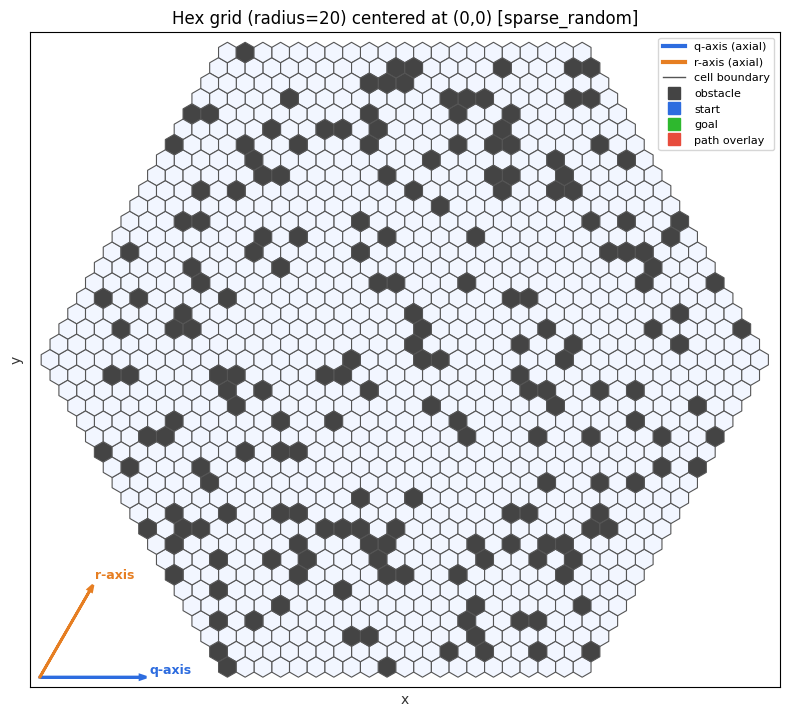

In [58]:
plot_map_config(scenarios[0])

In [59]:
AGENT_PARMS = {
    'a_max': 5,
    'a_min': 10,
    'max_turn_gs': 9,
    'collision_radius': 0,
    'start_v': VelocityState(0, None),
    'goal_v': None,
}

SEARCH_PARMS = {
    'jps_horizon': 1,
    'n_step': 1,
}

In [60]:
res_astar = run_benchmark(
    scenarios, 
    problem_class=AStarProblem, 
    search_class=AStarSearch, 
    h_func=h_cost_distance , 
    agent_parms = AGENT_PARMS, 
    search_parms = SEARCH_PARMS,
    num_runs=10)

In [61]:
res_hstar = run_benchmark(
    scenarios, 
    problem_class=HStarProblem, 
    search_class=HStarSearch, 
    h_func=h_cost_travel_time , 
    agent_parms = AGENT_PARMS, 
    search_parms = SEARCH_PARMS,
    num_runs=10)


In [62]:
import math
from typing import List, Dict, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def benchmark_results_to_df(results: List[Dict[str, float]], label: Optional[str] = None) -> pd.DataFrame:
    """
    Convert benchmark result dicts into a pandas DataFrame.
    Optionally attach a planner label column.
    """
    if not results:
        cols = [
            "length",
            "turn_per_length",
            "curv_per_length",
            "curv_sq_per_length",
            "max_curvature",
        ]
        df = pd.DataFrame(columns=cols)
    else:
        df = pd.DataFrame(results)

    if label is not None:
        df["planner"] = label
    return df


def combine_benchmark_results(
    results_a: List[Dict[str, float]],
    results_b: List[Dict[str, float]],
    labels: Tuple[str, str] = ("A*", "H*"),
) -> pd.DataFrame:
    """
    Combine two benchmark result lists into one labeled DataFrame.
    """
    df_a = benchmark_results_to_df(results_a, label=labels[0])
    df_b = benchmark_results_to_df(results_b, label=labels[1])
    return pd.concat([df_a, df_b], ignore_index=True)


def _safe_metric_values(df: pd.DataFrame, metric: str, planner: str) -> np.ndarray:
    """
    Return numeric non-NaN values for one metric/planner subset.
    """
    vals = df.loc[df["planner"] == planner, metric].dropna().to_numpy(dtype=float)
    return vals


def plot_length_comparison_boxplot(
    results_a: List[Dict[str, float]],
    results_b: List[Dict[str, float]],
    labels: Tuple[str, str] = ("A*", "H*"),
    figsize=(6, 5),
    save_path: Optional[str] = None,
):
    """
    Simple boxplot comparing path length between two planners.
    """
    df = combine_benchmark_results(results_a, results_b, labels=labels)

    vals_a = _safe_metric_values(df, "length", labels[0])
    vals_b = _safe_metric_values(df, "length", labels[1])

    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot([vals_a, vals_b], tick_labels=list(labels))
    ax.set_title("Path Length Comparison")
    ax.set_ylabel("Length")
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax


def plot_curvature_comparison_boxplot(
    results_a: List[Dict[str, float]],
    results_b: List[Dict[str, float]],
    metric: str = "curv_sq_per_length",
    labels: Tuple[str, str] = ("A*", "H*"),
    figsize=(6, 5),
    save_path: Optional[str] = None,
):
    """
    Simple boxplot comparing one curvature metric between two planners.

    Recommended metrics:
      - "curv_per_length"
      - "curv_sq_per_length"
      - "turn_per_length"
    """
    df = combine_benchmark_results(results_a, results_b, labels=labels)

    if metric not in df.columns:
        raise ValueError(f"Metric not found: {metric}")

    vals_a = _safe_metric_values(df, metric, labels[0])
    vals_b = _safe_metric_values(df, metric, labels[1])

    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot([vals_a, vals_b], tick_labels=list(labels))
    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax


def plot_curvature_overlay_histogram(
    results_a: List[Dict[str, float]],
    results_b: List[Dict[str, float]],
    metric: str = "curv_sq_per_length",
    labels: Tuple[str, str] = ("A*", "H*"),
    bins: int = 10,
    figsize=(7, 5),
    alpha: float = 0.6,
    save_path: Optional[str] = None,
):
    """
    Overlay histogram for one curvature metric.
    Good for seeing distribution shift between planners.
    """
    df = combine_benchmark_results(results_a, results_b, labels=labels)

    if metric not in df.columns:
        raise ValueError(f"Metric not found: {metric}")

    vals_a = _safe_metric_values(df, metric, labels[0])
    vals_b = _safe_metric_values(df, metric, labels[1])

    if len(vals_a) == 0 or len(vals_b) == 0:
        raise ValueError("One of the result sets has no values for the requested metric.")

    # Shared bins across both planners
    all_vals = np.concatenate([vals_a, vals_b])
    vmin = float(np.min(all_vals))
    vmax = float(np.max(all_vals))

    fig, ax = plt.subplots(figsize=figsize)

    if np.isclose(vmin, vmax):
        # constant case
        ax.bar([vmin - 0.5e-9], [len(vals_a)], width=1e-9, alpha=alpha, label=labels[0])
        ax.bar([vmin + 0.5e-9], [len(vals_b)], width=1e-9, alpha=alpha, label=labels[1])
        ax.set_xlim(vmin - 1, vmax + 1) if vmin == 0 else ax.set_xlim(vmin * 0.999, vmax * 1.001)
    else:
        actual_bins = min(bins, max(5, len(np.unique(np.round(all_vals, 12)))))
        edges = np.linspace(vmin, vmax, actual_bins + 1)
        ax.hist(vals_a, bins=edges, alpha=alpha, label=labels[0])
        ax.hist(vals_b, bins=edges, alpha=alpha, label=labels[1])

    ax.set_title(f"{metric} Distribution")
    ax.set_xlabel(metric)
    ax.set_ylabel("Count")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax


def plot_length_vs_curvature_scatter(
    results_a: List[Dict[str, float]],
    results_b: List[Dict[str, float]],
    curvature_metric: str = "curv_sq_per_length",
    labels: Tuple[str, str] = ("A*", "H*"),
    figsize=(7, 6),
    save_path: Optional[str] = None,
):
    """
    Scatter plot of length vs curvature metric, colored by planner.
    This is the cleanest tradeoff plot.
    """
    df = combine_benchmark_results(results_a, results_b, labels=labels)

    if "length" not in df.columns:
        raise ValueError("Metric not found: length")
    if curvature_metric not in df.columns:
        raise ValueError(f"Metric not found: {curvature_metric}")

    fig, ax = plt.subplots(figsize=figsize)

    for planner in labels:
        sub = df[df["planner"] == planner]
        ax.scatter(sub["length"], sub[curvature_metric], label=planner)

    ax.set_title(f"Length vs {curvature_metric}")
    ax.set_xlabel("length")
    ax.set_ylabel(curvature_metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    return fig, ax


In [63]:
def plot_astar_vs_hstar_report(
    res_astar: List[Dict[str, float]],
    res_hstar: List[Dict[str, float]],
    labels: Tuple[str, str] = ("A*", "H*"),
    curvature_metric: str = "curv_sq_per_length",
):
    """
    Generate a small set of useful comparison charts:
      1) length boxplot
      2) curvature boxplot
      3) curvature histogram
      4) length-vs-curvature scatter
    """
    plot_length_comparison_boxplot(res_astar, res_hstar, labels=labels)
    plot_curvature_comparison_boxplot(
        res_astar,
        res_hstar,
        metric=curvature_metric,
        labels=labels,
    )
    plot_curvature_overlay_histogram(
        res_astar,
        res_hstar,
        metric=curvature_metric,
        labels=labels,
    )
    plot_length_vs_curvature_scatter(
        res_astar,
        res_hstar,
        curvature_metric=curvature_metric,
        labels=labels,
    )

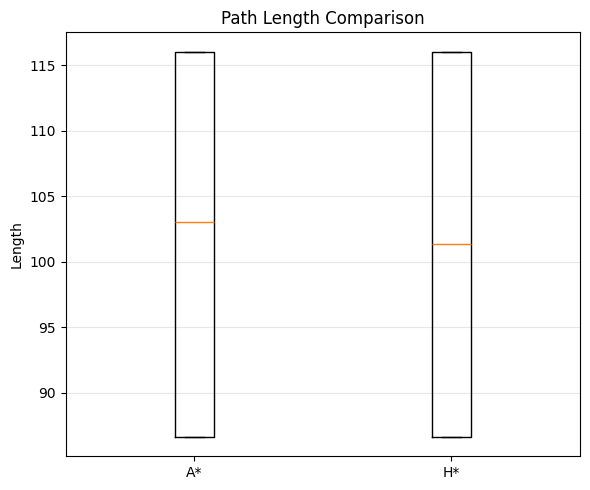

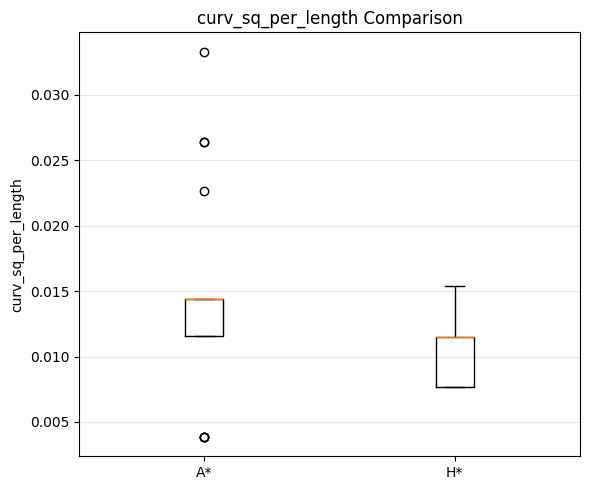

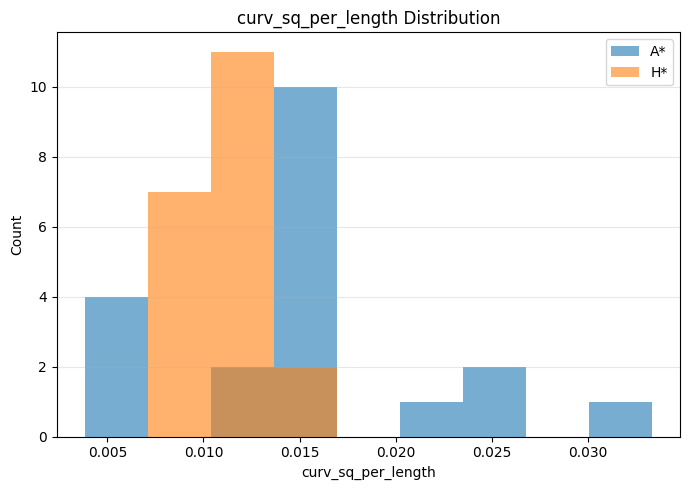

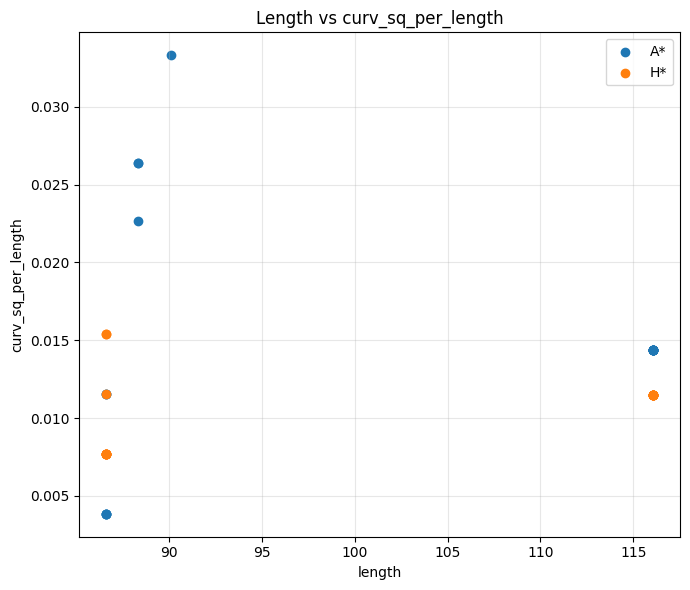

In [64]:
plot_astar_vs_hstar_report(res_astar, res_hstar)